In [1]:
import os,sys
sys.path.append("Cscope control driver")

from tqdm import tqdm
from IPython.display import clear_output
import ipywidgets as widgets
from cscope_class import CScope

import CleverscopeInterface
from T_AcquireSpec import T_AcquireSpec, T_AcquireAction, T_SigGenWaveform, T_LinkPort, T_TrigChannel, T_TrigSlope
from T_ChannelSpec import T_ChannelSpec, T_Probe, T_GlobalFilter, T_PreFilter20MHz, T_MA_Filter, T_ExpFilter, T_FilterOption, T_Coupling
from T_InterfaceSpec import T_InterfaceSpec, T_Interface
from T_ReplaySpec import T_ReplaySpec
from T_T0dt import T_T0dt
from CleverscopeClasses import T_CAUStatus, T_Command, T_FunctionCommand, T_LinkMasterSlave, T_TriggeringUnit
from time import sleep, time
import ctypes
import numpy as np

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import butter, sosfiltfilt, hilbert, periodogram, decimate, filtfilt
from scipy.signal import find_peaks

ch_names = ["A", "B", "C", "D"]
ch_colors = ["red", "blue", "green", "orange"]

# Connect to Cleverscope

In [3]:
CscopeUnitA = CScope()
CscopeUnitA.connect(start_time_s=-1e-3, stop_time_s=1e-3, 
                    trigger_level_v=1.0, trigger_channel=T_TrigChannel.T_TrigChan_ChanD,
                    probe_range_v=(-1.0, 1.0),
                    sampling_rate_hz=400e6)

hw_info = CscopeUnitA.DisplayHardwareInfo()

Initializing Scope (EQ10014)...
Success: Connected to EQ10014

   CLEVERSCOPE HARDWARE INFO
 Serial Number   : EQ10014
 Model (CAU)     : CS448
 ADC Resolution  : 14-bit
 Analog Channels : 4
----------------------------------------
 SigGen Option   : CS448 SG
 IP Address      : N/A
 TCP Port        : -1



# Disconnect from Scope

In [9]:
CscopeUnitA.disconnect()


###### DISCONNECT ROUTINE ######
Sending Close commands to hardware...
Hardware handle closed.
________________________________________



# Update Settings

In [19]:
volt_ranges = [(-0.5, 0.5),
              (-0.2, 0.2),
              (-1, 1),
              (-5, 5)]
couplings = ["AC", "AC", "AC", "DC"]

CscopeUnitA.update_time_axis(-500*1e-6,6.5e-3, 100e6) # start, stop, sample rate S/s
for i in range(4):
    CscopeUnitA.set_ch_range(i, volt_ranges[i][0], volt_ranges[i][1]) 
    CscopeUnitA.set_ch_coupling(i, coupling=couplings[i]) 
CscopeUnitA.update_trigger("D", TriggerLevel=1, TriggerType="Rising")

CscopeUnitA.probe_settings(True); # display probe settings


 CURRENT CHANNEL SETTINGS
 Ch |   Min (V)  |   Max (V)  |  Coupling  |   Probe (Gain)
----|------------|------------|------------|----------------
  A |     -0.500 |      0.500 |     AC     |       x1      
  B |     -0.200 |      0.200 |     AC     |       x1      
  C |     -1.000 |      1.000 |     AC     |       x1      
  D |     -5.000 |      5.000 |     DC     |       x1      



# Single Acquisition

Captured: 1,400,027 samples | Duration: 7000.1 us | Range: -500.0 to 6500.1 us
Sampling: 200.000 MS/s | dt: 5.0 ns | Nyquist: 100.0 MHz
V_Ranges: A:[-0.47, 0.50]  B:[-0.26, 0.38]

 CURRENT CHANNEL SETTINGS
 Ch |   Min (V)  |   Max (V)  |  Coupling  |   Probe (Gain)
----|------------|------------|------------|----------------
  A |     -0.500 |      0.500 |     AC     |       x1      
  B |     -0.200 |      0.200 |     AC     |       x1      
  C |     -1.000 |      1.000 |     AC     |       x1      
  D |     -5.000 |      5.000 |     DC     |       x1      



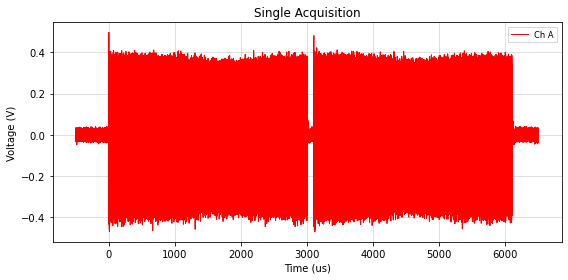

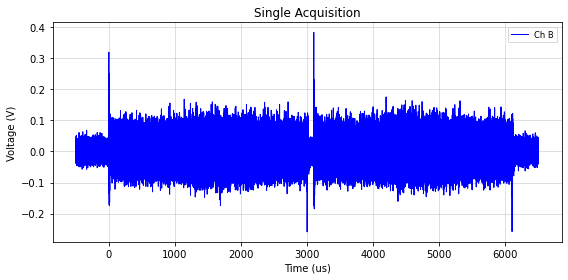

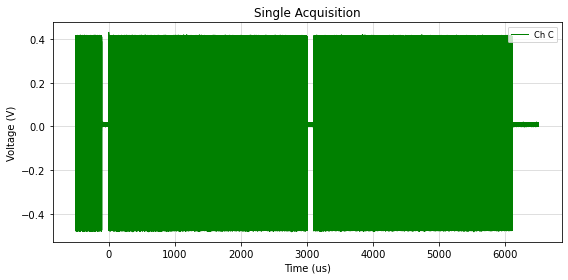

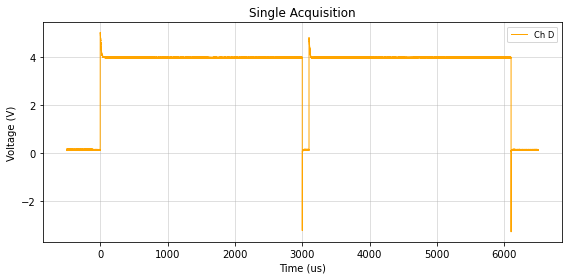

In [6]:
# AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Automatic
# AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Single
AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Triggered

t, scope_out = CscopeUnitA.get_single_acquisition(AcquisitionTypeToDo)
units, scale = 'us', 1e6
show = [0, 1, 2, 3]

if t is not None and len(t) > 1:
    # Calc Metrics
    dt = t[1] - t[0]
    fs = 1.0 / dt
    duration = t[-1] - t[0]
    
    # Simple Print
    print(f"Captured: {len(t):,} samples | Duration: {duration*1e6:.1f} us | Range: {t[0]*1e6:.1f} to {t[-1]*1e6:.1f} us")
    print(f"Sampling: {fs/1e6:.3f} MS/s | dt: {dt*1e9:.1f} ns | Nyquist: {fs/2e6:.1f} MHz")
    print(f"V_Ranges: A:[{np.min(scope_out[0]):.2f}, {np.max(scope_out[0]):.2f}]  B:[{np.min(scope_out[1]):.2f}, {np.max(scope_out[1]):.2f}]")

    settings=CscopeUnitA.probe_settings(True) # display probe settings


    
    for i in show:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.set(title="Single Acquisition", xlabel=f"Time ({units})", ylabel="Voltage (V)")
        ax.grid(True, alpha=0.5)
        colors, labels = ['r', 'b', 'g', 'orange'], ['Ch A', 'Ch B', 'Ch C', 'Ch D']
        ax.plot(t* scale, scope_out[i], color=colors[i], label=labels[i], lw=1)
            
        ax.legend(loc='upper right', fontsize='small')
        plt.tight_layout()
#         plt.xlim(1999, 2001)
        plt.show()
else:
    print("Error: No data captured.")
    

# AUTO RUN

In [ ]:
# settings

units, scale = 'ms', 1e3
AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Triggered
show_channels = [1,2] 
max_plot_points = 50_000
sleep_time = 0.5



stats_html = widgets.HTML(
    value="<b>Status:</b> Ready to start...",
    placeholder='Stats will appear here',
)

# Display the Control Panel
ui = widgets.VBox([stats_html])
display(ui)


plt.ioff() # Prevent double-display in some notebooks
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_title("Live Scope View (press 'q' to stop)")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Voltage (V)")
ax.grid(True, alpha=0.5)

# Initialize 4 empty lines (one for each channel)
lines = []
colors = ['r', 'b', 'g', 'orange']
labels = ['Ch A', 'Ch B', 'Ch C', 'Ch D']
scales = [1, 1, 1, 1]

for i in range(4):
    line, = ax.plot([], [], color=colors[i], label=labels[i], lw=1)
    lines.append(line)

ax.legend(loc='upper right', fontsize='small')

# Create a "Display Handle" - this is the ID we will use to update the plot later
plot_handle = display(fig, display_id=True)

# --- 3. MAIN LOOP ---


while not keyboard.is_pressed('q'):
    try:
        # A. ACQUIRE
        t, scope_out = CscopeUnitA.get_single_acquisition(AcquisitionTypeToDo)
        
        if t is not None and len(t) > 1:
            
            # --- B. PROCESS DATA (Decimation) ---
            total_points = len(t)
            step = max(1, int(round(total_points / max_plot_points)))
            
            # --- C. UPDATE PLOT LINES (Don't redraw figure, just update data) ---
            # We calculate scale ONCE for efficiency
            t_scaled = t[::step] * 1e6 # Convert to us
            
            # Find min/max for auto-scaling the axes
            y_min_global = 0
            y_max_global = 0
            
            for i in range(4):
                if i in show_channels and i < len(scope_out):
                    # Update X and Y data for this line
                    y_data = scales[i]*scope_out[i][::step]
                    lines[i].set_data(t_scaled, y_data)
                    
                    # Track min/max for scaling
                    y_min_global = min(y_min_global, np.min(y_data))
                    y_max_global = max(y_max_global, np.max(y_data))
                else:
                    # Clear data for hidden channels
                    lines[i].set_data([], [])

            # --- D. UPDATE AXIS LIMITS ---
            # Matplotlib doesn't auto-scale when using set_data, so we do it manually
            ax.set_xlim(t_scaled[0], t_scaled[-1])
            
            # Add 10% headroom to voltage axis
            span = y_max_global - y_min_global
            if span == 0: span = 1 # prevent error on flat line
            ax.set_ylim(y_min_global - 0.1*span, y_max_global + 0.1*span)
#             ax.set_ylim(0, 3)
            
            # --- E. UPDATE THE DISPLAY ---
            # This swaps the old image with the new one efficiently
            plot_handle.update(fig)
            
            # --- F. UPDATE TEXT WIDGET ---
            # Instead of print(), we set the .value of the HTML widget
            dt = t[1] - t[0]
            fs = 1.0/dt
            stats_html.value = (
                f"<b>Last Capture:</b> {total_points:,} pts | "
                f"<b>Rate:</b> {fs/1e6:.2f} MS/s | "
                f"<b>Decimation:</b> 1:{step}<br>"
                f"<b>Ranges:</b> A:[{np.min(scope_out[0]):.2f}, {np.max(scope_out[0]):.2f}] V"
            )

        else:
            stats_html.value = "<b>Status:</b> Waiting for Trigger..."
        
        # UI Responsiveness
        sleep(sleep_time)

    except Exception as e:
        stats_html.value = f"<b>Error:</b> {str(e)}"

plt.close(fig) # Cleanup memory when loop ends
print("Acquisition Stopped.")

# SoF Calibration

In [ ]:
data_ch = 1

def lorentzian(x, y0, A, x0, gamma):
    return y0 + A * (0.5 * gamma)**2 / ((x - x0)**2 + (0.5 * gamma)**2)

AcqType = T_AcquireAction.T_AcquireAction_Automatic
t, scope_out = CscopeUnitA.get_single_acquisition(CscopeUnitA, AcqType)


if t is not None:
    fit_and_plot_cavity(t, scope_out[data_ch], label="Channel A (Trans)",SCAN_RATE_HZ_S=400e3/20e-3 )
else:
    print("Error: No data captured.")



## Length Calibration

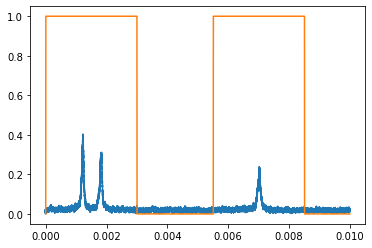

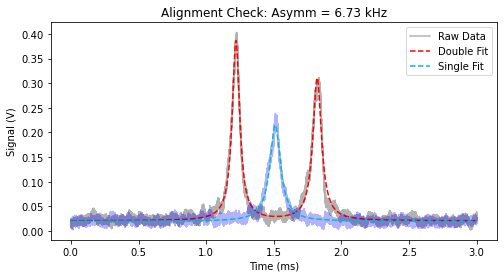

Calculated Asymmetry: 6.731 kHz
Measured VRS: 0.200 MHz
...

KeyboardInterrupt: 

In [8]:
# single shot
f_scan_range = 1e6  # Hz
t_scan = 3e-3         # seconds
# Scale factor: (Hz / s) * 1e-3 -> kHz / s
SCALE_KHZ_S = (f_scan_range / t_scan) * 1e-3
asymms_arr = []
clr_asymms = True
# --- ACQUIRE ---
for _ in range(10):
    AcqType = T_AcquireAction.T_AcquireAction_Triggered
    t, scope_out = CscopeUnitA.get_single_acquisition(AcqType)


    clr_asymms = False
    if clr_asymms:
        asymms_arr = []

    if t is not None:
        # Map Channels (Adjust as needed)
        sig_data = scope_out[2] # Channel A (Signal)
        ttl_data = scope_out[3] # Channel D (TTL Trigger)
        
        plt.plot(t, sig_data)
        plt.plot(t, ttl_data > 3)

        # Run Calculation
        clear_output(wait=True)
        asymm, pm1, p1, p0 = get_asymmetry(t, sig_data, ttl_data, SCALE_KHZ_S, verify=True)    
        print(f"Calculated Asymmetry: {asymm:.3f} kHz")
        print(f"Measured VRS: {(p1-pm1) / t_scan * f_scan_range * 1e-6 :.3f} MHz")
        asymms_arr.append(asymm)



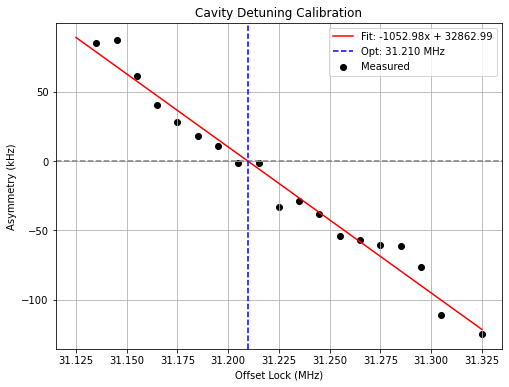

Optimal Offset Point: 31.2096 MHz


In [80]:
## full scan
f_scan_range = 1e6  # Hz
t_scan = 2e-3         # seconds
# Scale factor: (Hz / s) * 1e-3 -> kHz / s
SCALE_KHZ_S = (f_scan_range / t_scan) * 1e-3

detuning_range = 0.2 # MHz
N = 21 # Number of points
f0 = 31.125 # MHz
detunings = np.linspace(f0, f0 + detuning_range, N)
asymm_list = []

print(f"Starting Scan over {N} points...")

for i, det in enumerate(detunings):
    print(f"Shot {i+1}/{N} (Detuning: {det:.3f} MHz)...")
    # If Live:
    t, scope_out = CscopeUnitA.get_single_acquisition(T_AcquireAction.T_AcquireAction_Single)
    if t is None:
        asymm_list.append(np.nan)
        continue
        
    sig = scope_out[2]
    ttl = scope_out[3]
    
    # --- PROCESS ---
    # verify=False to suppress popping up 20 windows
    clear_output(wait=True)
    asymm, pm1, p1, p0 = get_asymmetry(t, sig, ttl, SCALE_KHZ_S, verify=True)
    
    asymm_list.append(asymm)

# --- PLOT RESULTS ---
asymm_arr = np.array(asymm_list)
valid_mask = ~np.isnan(asymm_arr)
skip_indices = []
for i in skip_indices:
    valid_mask[i] = 0

if np.sum(valid_mask) > 5:
    # Linear Fit
    # Polyfit returns [slope, intercept]
    slope, intercept = np.polyfit(detunings[valid_mask], asymm_arr[valid_mask], 1)
    
    # Find zero crossing: 0 = slope*x + intercept  -> x = -intercept/slope
    optimal_offset = -intercept / slope
    
    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(detunings[valid_mask], asymm_arr[valid_mask], color='k', label='Measured')
    
    fit_line = slope * detunings + intercept
    plt.plot(detunings, fit_line, 'r-', label=f'Fit: {slope:.2f}x + {intercept:.2f}')

    # Markers
    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(optimal_offset, color='b', linestyle='--', label=f'Opt: {optimal_offset:.3f} MHz')
    
    plt.xlabel("Offset Lock (MHz)")
    plt.ylabel("Asymmetry (kHz)")
    plt.title("Cavity Detuning Calibration")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print(f"Optimal Offset Point: {optimal_offset:.4f} MHz")
else:
    print("Not enough valid points for a fit.")

## noise floor meas

In [ ]:
# testing noise floor
AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Automatic
t, scope_out = CscopeUnitA.get_single_acquisition(CscopeUnitA, AcquisitionTypeToDo)

data_source = "50 Ohm Noise Floor"
t = np.array(t); 
sig = np.array(scope_out[0]) # ch A
dt = np.mean(np.diff(t))
fs = 1.0 / dt
R_load = 50.0
sig_ac = sig - np.mean(sig)

f, pxx = periodogram(sig_ac, fs, window='boxcar', scaling='density')
v_density = np.sqrt(pxx)                # V/rtHz
psd_watts = pxx / R_load                # Watts/Hz
psd_dBmHz = 10 * np.log10(psd_watts * 1000 + 1e-20) 

target_freq = 2e6  # 2 MHz
window_width = 100

# Find index closest to target frequency
idx = np.argmin(np.abs(f - target_freq))
idx_start = max(0, idx - window_width)
idx_end = min(len(f), idx + window_width)

# Calculate means
avg_floor_VrtHz = np.mean(v_density[idx_start : idx_end])
avg_floor_dBmHz = np.mean(psd_dBmHz[idx_start : idx_end])

# --- 3. PLOTTING ---
fig = plt.figure(figsize=(10, 8))
# Super Title
plt.suptitle(f"Data Source: {data_source}", fontsize=14, fontweight='bold')

# --- Subplot 1: Time Domain ---
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(t[::100] * 1e3, sig[::100] * 1e3, color=(0.2, 0.2, 0.7), linewidth=1)

ax1.set_title('Time Domain Trace')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Amplitude (mV)')
ax1.grid(True, which='both', linestyle='--')
ax1.autoscale(enable=True, axis='x', tight=True)

# --- Subplot 2: Frequency Domain ---
ax2 = fig.add_subplot(2, 1, 2)
ax2.semilogx(f * 1e-6, psd_dBmHz, color=(0.8, 0.2, 0.2), linewidth=1.5)

for freq_mhz, label in zip([1, 2], ['Het. Tone 1', 'Het. Tone 2']):
    ax2.axvline(x=freq_mhz, color='k', linestyle='--', label=label)

ax2.set_title('Power Spectral Density')
ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylabel('Noise Power (dBm/Hz)')
ax2.grid(True, which='both', linestyle='--')

# Set Limits
ax2.set_xlim([1e-3, (fs / 2) * 1e-6])
# ax2.set_ylim([-200, -50])

stats_text = (
    f"$\\bf{{Noise\ at\ {target_freq/1e6:.1f}\ MHz:}}$\n"
    f"{avg_floor_VrtHz * 1e9:.2f} nV/$\\sqrt{{Hz}}$\n"
    f"{avg_floor_dBmHz:.2f} dBm/Hz"
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='black')
ax2.text(0.2, 0.25, stats_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()





# heterodyne processing

In [ ]:
f_idx = 0

In [ ]:
## heterodyne processing

for idx in range(1):
    
    AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Triggered
    t, scope_out = CscopeUnitA.get_single_acquisition(AcquisitionTypeToDo)
    if len(t)==0:
        raise Exception("No Data Collected...")
    else:
        f_idx += 1
    t = np.array(t)
    sig = np.array(scope_out[0]) # ch A
    ref = np.array(scope_out[2]) # ch C

    f_center1 = 2.5e6
    f_center2 = 3.5e6
    Fs = 1/np.mean(np.diff(t))

    mag1, phase1, I1, Q1 = demodulate_beatnote(sig, ref, f_center1, Fs, digital_mix=True)
    mag2, phase2, I2, Q2 = demodulate_beatnote(sig, ref, f_center2, Fs, digital_mix=True)
#     save_data(t, mag, phase, I, Q, "bistab_power2", f_idx, 10)
#     save_raw_data(t, sig, ref, "raw_analysis_check", idx)
    axs = plot_IQ_data(t, sig, mag1, phase1, I1, Q1)
    axs = plot_IQ_data(t, sig, mag2, phase2, I2, Q2)
    print(idx)




# Heterodyne Scans

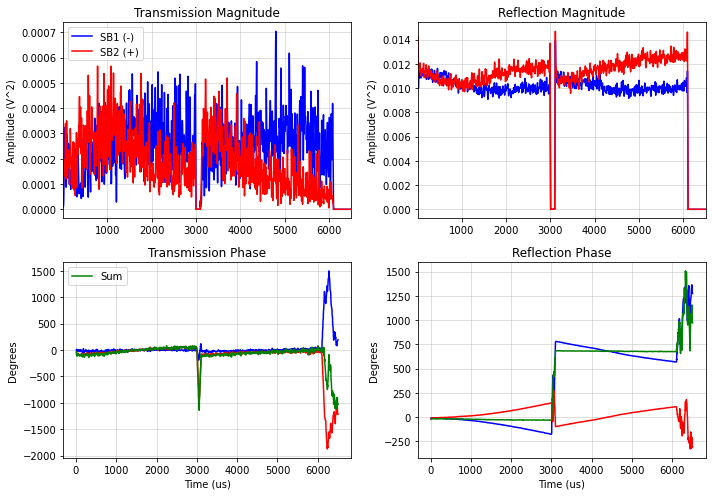

.

TypeError: object of type 'NoneType' has no len()

In [47]:
reflection = True
transmission = True
N = 100
AcquisitionTypeToDo = T_AcquireAction.T_AcquireAction_Triggered

f_center = 3.6e6
digital_mix_f = 500e3
mix_phase=0

active_channels = []
if transmission: active_channels.append('T')
if reflection: active_channels.append('R')

cols = len(active_channels)

for idx in range(N):
    # 1. DATA ACQUISITION
    t, scope_out = CscopeUnitA.get_single_acquisition(AcquisitionTypeToDo) 
    
    if len(t) == 0:
        print("No Data Collected...")
        sleep(1)
        continue

    t = np.array(t)
    Fs = 1/np.mean(np.diff(t))
    mask = (t > 0.01e-3) # Mask for phase plotting

    # Dictionary to store results for easy access during plotting
    results = {}

    # 2. SIGNAL PROCESSING
    raw_signals = {'R': np.array(scope_out[0]), 'T': np.array(scope_out[1])}
    ref_eom = np.array(scope_out[2])
    ref_mixed = ref_eom * np.sin(t * 2 * np.pi * digital_mix_f + mix_phase)

    for ch in active_channels:
        sig = raw_signals[ch]
        # Demodulate sideband 1
        m1, p1, i1, q1 = demodulate_beatnote(sig, ref_mixed, f_center - digital_mix_f, Fs, 
                                           digital_mix=False, f_lp=50e3, f_bw=600e3)
        # Demodulate sideband 2
        m2, p2, i2, q2 = demodulate_beatnote(sig, ref_mixed, f_center + digital_mix_f, Fs, 
                                           digital_mix=False, f_lp=50e3)
        results[ch] = {'m1': m1, 'p1': p1, 'm2': m2, 'p2': p2, 'i1': i1, 'q1': q1, 'i2': i2, 'q2': q2}

    # 3. PLOTTING
    clear_output(wait=True)
    if cols == 0: 
        print("No channels selected for plotting.")
        break
        
    fig, axes = plt.subplots(nrows=2, ncols=cols, figsize=(5 * cols, 7), squeeze=False)

    for i, ch in enumerate(active_channels):
        res = results[ch]
        title_prefix = "Transmission" if ch == 'T' else "Reflection"
        
        # --- Row 0: Magnitude ---
        ax_mag = axes[0, i]
        ax_mag.plot(t * 1e6, res['m1'], color='blue', label='SB1 (-)')
        ax_mag.plot(t * 1e6, res['m2'], color='red', label='SB2 (+)')
        ax_mag.set_title(f"{title_prefix} Magnitude")
        ax_mag.set_ylabel("Amplitude (V^2)")
        ax_mag.grid(True, alpha=0.5)
        ax_mag.set_xlim(10, t[-1] * 1e6)
        if i == 0: ax_mag.legend()

        # --- Row 1: Phase ---
        ax_phase = axes[1, i]
        p1_unwrapped = np.unwrap(np.degrees(res['p1'][mask]))
        p2_unwrapped = np.unwrap(np.degrees(res['p2'][mask]))
        
        ax_phase.plot(t[mask] * 1e6, p1_unwrapped, color='blue')
        ax_phase.plot(t[mask] * 1e6, p2_unwrapped, color='red')
        ax_phase.plot(t[mask] * 1e6, p1_unwrapped + p2_unwrapped, color='green', label='Sum')
        ax_phase.set_title(f"{title_prefix} Phase")
        ax_phase.set_ylabel("Degrees")
        ax_phase.set_xlabel("Time (us)")
        ax_phase.grid(True, alpha=0.5)
        if i == 0: ax_phase.legend()

    plt.tight_layout()
    plt.show()
    
    save_data(t*1e6, results['R']['m1'], results['R']['p1'],  results['R']['i1'], results['R']['q1'], 'atom_count_attempt1R1_lp_0khz', idx+89, downsample_factor=100)
    save_data(t*1e6, results['R']['m2'], results['R']['p2'],  results['R']['i2'], results['R']['q2'], 'atom_count_attempt1R2_lp_0khz', idx+89, downsample_factor=100)
    save_data(t*1e6, results['T']['m1'], results['T']['p1'],  results['T']['i1'], results['T']['q1'], 'atom_count_attempt1T1_lp_0khz', idx+89, downsample_factor=100)
    save_data(t*1e6, results['T']['m2'], results['T']['p2'],  results['T']['i2'], results['T']['q2'], 'atom_count_attempt1T2_lp_0khz', idx+89, downsample_factor=100)


In [31]:

# index=3
# save_data(t*1e6, results['R']['m1'], results['R']['p1'], np.zeros(len(m1)), np.zeros(len(m1)), 'IQ_number_convR1', index, downsample_factor=100)
# save_data(t*1e6, results['R']['m2'], results['R']['p2'], np.zeros(len(m2)), np.zeros(len(m2)), 'IQ_number_convR2', index, downsample_factor=100)
# save_data(t*1e6, results['T']['m1'], results['T']['p1'], np.zeros(len(m1)), np.zeros(len(m1)), 'IQ_number_convT1', index, downsample_factor=100)
# save_data(t*1e6, results['T']['m2'], results['T']['p2'], np.zeros(len(m2)), np.zeros(len(m2)), 'IQ_number_convT2', index, downsample_factor=100)


Optimal DC Offset (x0): -2.7561 mV


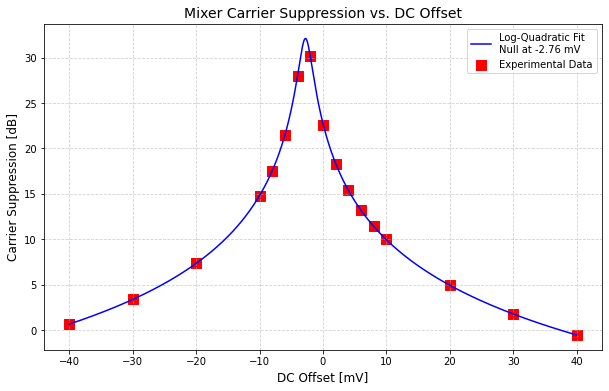

In [88]:
mv = [-40, -30, -20, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 20, 30, 40]
power_dbm = -18.2-  np.array([-18.9, -21.6, -25.6, -33, -35.7, -39.7, -46.2, -48.4, -40.8, -36.5, -33.6, -31.4, -29.7, -28.2, -23.2, -20, -17.7]) 

# 2. Define the Log-Quadratic Model
# Suppression(dB) = C - 10 * log10( a * (V - x0)^2 + b )
def log_quadratic_model(x, x0, a, b, c):
    return c - 10 * np.log10(a * (x - x0)**2 + b)

# 3. Perform the Fit
# p0 is the initial guess: [center_offset, curvature, floor, vertical_shift]
initial_guess = [-2.7, 0.01, 0.01, 15]
popt, pcov = curve_fit(log_quadratic_model, mv, power_dbm, p0=initial_guess)

# 4. Extract Results
x0_opt, a_opt, b_opt, c_opt = popt
print(f"Optimal DC Offset (x0): {x0_opt:.4f} mV")

# 5. Generate Fit Line for Plotting
x_fit = np.linspace(min(mv), max(mv), 1000)
y_fit = log_quadratic_model(x_fit, *popt)

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(mv, power_dbm, marker='s', color='red', label='Experimental Data', s=100)
plt.plot(x_fit, y_fit, color='blue', label=f'Log-Quadratic Fit\nNull at {x0_opt:.2f} mV')

plt.title("Mixer Carrier Suppression vs. DC Offset", fontsize=14)
plt.xlabel("DC Offset [mV]", fontsize=12)
plt.ylabel("Carrier Suppression [dB]", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

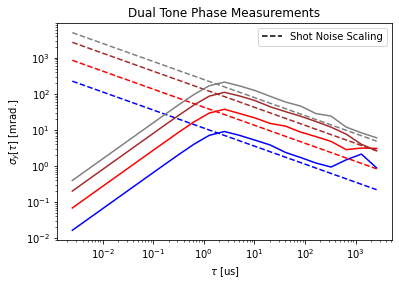

In [36]:
ad = [adevs_sum_1, adevs_sum_2, adevs_sum_3, adevs_sum_4,adevs_sum_5, adevs_sum_6]
means = [mean_1, mean_2, mean_3, mean_4, mean_5, mean_6]
colors = ['b','g', 'r', 'purple', 'brown', 'gray']

for i in range(6):
    if i == 1 or i== 3:
        continue
    plt.loglog(taus*1e6, ad[i]*1e3, color=colors[i])
    plt.loglog(taus*1e6, 1e3*np.sqrt(2)/(np.sqrt(taus * 1e6 * (means[i] / 1.96e-5))), color=colors[i], linestyle='--')





plt.plot([], [], '--k', label="Shot Noise Scaling")

plt.legend()
plt.xlabel(r"$\tau$ [us]")
plt.ylabel(r"$\sigma_y[\tau]$ [mrad.]")
plt.title("Dual Tone Phase Measurements")

plt.show()


In [206]:
## getting conversions
phaseR_cal = np.unwrap(phaseR[mask] - phase_car[mask])
phaseT_cal = np.unwrap(phaseT[mask])
t_cal = t[mask]
f_cal = t_cal * 200e3/10e-3
f_cal = f_cal - np.mean(f_cal)


def model_phaseT(f, f0, kappa, A, phi0):
    return phi0 + A*np.arctan(2*(f-f0)/kappa)

def model_phaseR(f, f0, kappa, A, phi0, B):
    return phi0 + np.arctan(A*(f-f0) / ((f-f0)**2 + kappa)) + B*f

poptT, pcovT = curve_fit(model_phaseT, f_cal, phaseT_cal, maxfev=20000, p0=[0, 28e3, 1, np.mean(phaseT_cal)])
poptR, pcovR = curve_fit(model_phaseR, f_cal, phaseR_cal, maxfev=20000, p0=[0, 1.7e8, 2e3,  np.mean(phaseR_cal), 0])

# transmission 
plt.plot(f_cal*1e-3, 1e3*phaseT_cal, label='data')
plt.plot(f_cal*1e-3, 1e3*model_phaseT(f_cal, *poptT), '--r', label='Fit')
plt.xlabel("Frequency [kHz]")
plt.ylabel("Phase [mrad.]")
plt.legend()
plt.text(f_cal[0]*1e-3, 1e3*np.mean(phaseT_cal), f'Slope [2A/K]:\n{np.round(1e6*2*poptT[2]/poptT[1],2)} mrad/kHz')
plt.title("Transmission Calibration")
plt.show()

#reflection
plt.plot(f_cal*1e-3, 1e3*phaseR_cal, label='data')
plt.plot(f_cal*1e-3, 1e3*model_phaseR(f_cal, *poptR), '--r', label='Fit')
plt.xlabel("Frequency [kHz]")
plt.ylabel("Phase [mrad.]")
plt.legend()
plt.text(f_cal[0]*1e-3, 1e3*np.mean(phaseR_cal), f'Slope [A/K]:\n{np.round(1e6*poptR[2]/poptR[1],2)} mrad/kHz')
plt.title("Reflection Calibration")
plt.show()

print(poptR)
print(poptT)

KeyboardInterrupt: 

# Allan Deviations

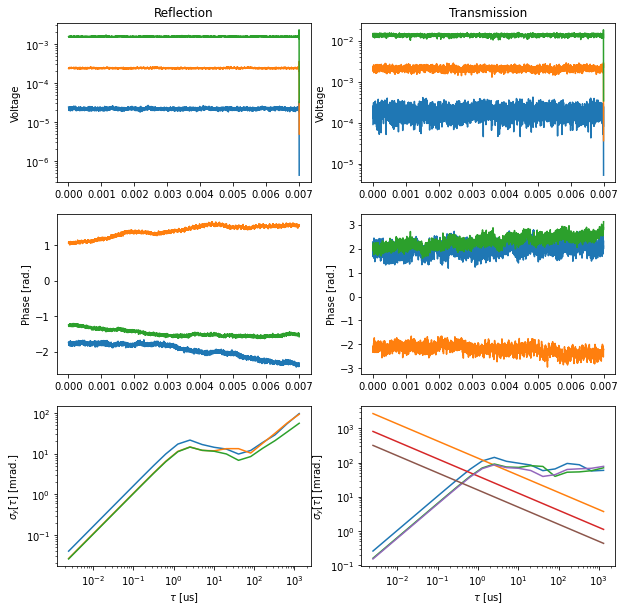

In [15]:
ts = [t_low, t_med, t_high]
scopes = [scope_out_low, scope_out_med, scope_out_high]
labels = ["Low", "Medium", 'High',]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,10))
[ax1, ax2, ax3, ax4, ax5, ax6]  = axes.flatten()

for i in range(3):
    t = ts[i]
    scope_out = scopes[i]

    mask  = np.where((t>0.01e-3) & (t<np.inf))


    sigT = np.array(scope_out[0]) # ch A
    sigR = np.array(scope_out[1]) # ch A
    ref = np.array(scope_out[2]) # ch c


    f_center1 = 3e6
    Fs = 1/np.mean(np.diff(t))

    
    magR, phaseR, IR, QR = demodulate_beatnote(sigR, ref, f_center1, Fs, digital_mix=False, f_lp=300e3)
    magT, phaseT, IT, QT = demodulate_beatnote(sigT, ref, f_center1, Fs, digital_mix=False, f_lp=300e3)

    
    taus, adevsT =  get_adev(phaseT[mask], t[mask])
    _, adevsR =  get_adev(phaseR[mask], t[mask])
    
    ax1.semilogy(t[mask], magR[mask])
    ax2.semilogy(t[mask], magT[mask])
    
    ax3.plot(t[mask], phaseR[mask])
    ax4.plot(t[mask], phaseT[mask])
    
    ax5.loglog(taus*1e6, adevsR*1e3)
    ax6.loglog(taus*1e6, adevsT*1e3)
    ax6.loglog(taus*1e6, 1e3/(2*np.sqrt(taus*1e6*np.mean(magT) / 1.4e-5)))

ax1.set_title("Reflection")
ax1.set_ylabel("Voltage")
ax2.set_title("Transmission")
ax2.set_ylabel("Voltage")

ax3.set_ylabel("Phase [rad.]")
ax4.set_ylabel("Phase [rad.]")

ax5.set_xlabel(r"$\tau$ [us]")
ax5.set_ylabel(r"$\sigma_y[\tau]$ [mrad.]")

ax6.set_xlabel(r"$\tau$ [us]")
ax6.set_ylabel(r"$\sigma_y[\tau]$ [mrad.]")

# plt.legend()
plt.show()




In [ ]:
# helper functions

In [2]:
def demodulate_beatnote(het, ref, f_center, Fs, f_bw=500e3, f_lp=100e3, digital_mix=True):
    """
    Demodulates a heterodyne signal (het) using a reference tone (ref).
    Returns Amplitude and Phase relative to the reference.
    """
    
    # Nyquist frequency
    nyq = 0.5 * Fs
    
    # ---------------------------------------------------------
    # 1. Bandpass the ref and beat note signals around f_center
    # ---------------------------------------------------------
    # Ensure lower bound is positive
    low = max(0.001, f_center - f_bw / 2)
    high = f_center + f_bw / 2
    
    sos_bp = butter(4, [low / nyq, high / nyq], btype='band', output='sos')
    het_bp = sosfiltfilt(sos_bp, het)
    if digital_mix:
        # digital mixing
        t = 1/Fs*np.arange(len(het))

        raw_i = het_bp * np.cos(t*2*np.pi*f_center)
        raw_q = het_bp * np.sin(t*2*np.pi*f_center)
    else:
        
        
        ref_bp = sosfiltfilt(sos_bp, ref)

        # normalize, make analytics then mix
        ref_norm = ref_bp / np.max(np.abs(ref_bp[int(len(ref)*0.25):int(len(ref)*0.75)]))
        ref_analytic = hilbert(ref_norm)

        # MIXING:
        raw_i = het_bp * np.real(ref_analytic)
        raw_q = het_bp * np.imag(ref_analytic)
    
    


    # ---------------------------------------------------------
    # 4. Low pass I and Q
    # ---------------------------------------------------------
    # Design Butterworth Lowpass filter to remove the 2*f_center component
    b_lp, a_lp = butter(4, f_lp / nyq, btype='low')
    
    i_demod = filtfilt(b_lp, a_lp, raw_i)
    q_demod = filtfilt(b_lp, a_lp, raw_q)

    # ---------------------------------------------------------
    # 5. Generate phase and magnitude vectors to return
    # ---------------------------------------------------------
    magnitude = 4* (i_demod**2 + q_demod**2)
    phase = np.arctan2(q_demod, i_demod)
    
    return magnitude, phase, i_demod, q_demod
    
def save_data(t, mag, phase, I, Q, base_filename, index, downsample_factor=100):
    """
    Safely downsamples demodulated data (anti-alias filter) and saves to a .txt file.
    
    Args:
        mag, phase, I, Q (arrays): The data vectors to save.
        base_filename (str): Prefix for the file.
        index (int): Shot index.
        downsample_factor (int): Decimation factor (e.g., 100).
    """
    
    
    # Note: We use ftype='fir' for a Finite Impulse Response filter 
    # which is generally safer for phase stability, or 'iir' for speed. 
    # For large factors (>13), 'decimate' automatically calls itself recursively.
    t_ds     = t[::downsample_factor]
    mag_ds   = decimate(mag, downsample_factor, ftype='fir')
    phase_ds = decimate(phase, downsample_factor, ftype='fir')
    I_ds     = decimate(I, downsample_factor, ftype='fir')
    Q_ds     = decimate(Q, downsample_factor, ftype='fir')
    
    L = min(len(t_ds), len(mag_ds)) # for fixing off by one errors
    
    # 2. Construct Filename
    filename = f"{base_filename}_{index}.txt"
    
    # 3. Save to Text File

    data_matrix = np.column_stack((t_ds[:L], mag_ds[:L], phase_ds[:L], I_ds[:L], Q_ds[:L]))
       
    # Header explains the columns
    header_txt = f"Downsample_Factor: {downsample_factor}\nColumns: Time, Magnitude, Phase(rad), I, Q"
    
    np.savetxt(
        filename, 
        data_matrix, 
        fmt='%.6e',     # Scientific notation with 6 decimals
        delimiter=',',  # Comma separated (CSV style)
        header=header_txt
    )
    
def save_raw_data(t, het, ref, base_filename, index):    
    # 2. Construct Filename
    filename = f"{base_filename}_{index}.txt"
    
    # 3. Save to Text File

    data_matrix = np.column_stack((t, het, ref))
       
    # Header explains the columns
    header_txt = f"Raw Data:\nColumns: Time, Het, Ref"
    
    np.savetxt(
        filename, 
        data_matrix, 
        fmt='%.6e',     # Scientific notation with 6 decimals
        delimiter=',',  # Comma separated (CSV style)
        header=header_txt
    )
    
def get_adev(y, t):
    """
    Computes the standard Allan deviation of a time series (Frequency Data).
    Replicates the logic of the provided MATLAB script.
    
    Inputs:
      y : Frequency data vector (fractional frequency deviation)
      t : Time-stamps vector (seconds)
      
    Outputs:
      tau  : Averaging times (s)
      adev : Allan deviation at each tau
    """
    # Ensure numpy arrays
    y = np.array(y)
    t = np.array(t)
    n = len(y)
    
    # Basic step (sampling interval)
    tau0 = np.mean(np.diff(t))
    
    # Maximum bin size = 2^jj such that 3*2^jj <= n-1
    # This ensures we have at least 3 blocks to average at the longest tau
    jj = int(np.floor(np.log2((n - 1) / 3)))
    
    taus = []
    adevs = []
    
    # Pre-calculate Cumulative Sum for fast averaging
    # equivalent to MATLAB: cY = cumsum([0; y])
    cY = np.cumsum(np.insert(y, 0, 0))
    
    # Loop through powers of 2 (Octave stepping)
    for j in range(jj + 1):
        m = 2**j
        current_tau = m * tau0
        
        # Calculate Block Averages using the integral (cumsum) method
        D = (cY[m:] - cY[:-m]) / m
        Dseg = D[::m]
        if len(Dseg) < 2:
            break
        av = 0.5 * np.mean(np.diff(Dseg)**2)
        
        taus.append(current_tau)
        adevs.append(np.sqrt(av))
        
    return np.array(taus), np.array(adevs)    

def fit_and_plot_cavity(t, sig, label="Signal", SCAN_RATE_HZ_S = 500e3/20e-3):
    # Convert Time -> Frequency (and center it for stability)
    f_raw = t * SCAN_RATE_HZ_S
    f = f_raw - np.mean(f_raw)
    
    y0_guess = np.mean(sig[:100])
    imax = np.argmax(sig) # Peak
    A_guess = sig[imax] - y0_guess        
    x0_guess = f[imax]
    gamma_guess = (np.max(f) - np.min(f)) / 10.0
    
    p0 = [y0_guess, A_guess, x0_guess, gamma_guess]
    
    # --- B. FIT ---
    try:
        popt, _ = curve_fit(lorentzian, f, sig, p0=p0)
        y0, A, x0, gamma = popt
    except Exception as e:
        print(f"Fit failed: {e}")
        return

    # --- C. CALCULATE METRICS ---
    # Point of max slope (Side of Fringe)
    dx = gamma / (2 * np.sqrt(3))
    f_side = x0 + dx 
    y_side = lorentzian(f_side, *popt)
    
    # Analytical Slope (Volts / Hz)
    slope_V_Hz = abs((3 * np.sqrt(3) / 4) * (A / gamma))
    slope_mV_kHz = slope_V_Hz * 1e6
    
    # --- D. PLOT ---
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # 1. Raw Data
    ax.plot(f*1e-3, sig*1e3, 'k', alpha=0.3, label='Raw Data')
    
    # 2. Fit Curve
    f_dense = np.linspace(min(f), max(f), 1000)
    y_fit = lorentzian(f_dense, *popt)
    ax.plot(f_dense*1e-3, y_fit*1e3, 'r-', lw=2, label='Lorentzian Fit')
    
    # 3. Mark Side-of-Fringe
    ax.plot(f_side*1e-3, y_side*1e3, 'bo', ms=8, label='Max Slope Pt')
    
    # 4. Text Stats
    stats = (
        f"Slope: {slope_mV_kHz:.2f} mV/kHz\n"
        f"Width ($\\Gamma$): {gamma*1e-3:.2f} kHz\n"
        f"Amp: {A*1e3:.1f} mV"
    )
    ax.text(0.05, 0.95, stats, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    # Formatting
    ax.set_title(f"Cavity Scan Fit: {label}")
    ax.set_xlabel("Frequency Detuning (kHz)")
    ax.set_ylabel("Voltage (mV)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='center right')
    
    # Zoom to feature
    span = 4 * abs(gamma)
#     ax.set_xlim((x0 - span)*1e-3, (x0 + span)*1e-3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"--- RESULTS ({label}) ---")
    print(f"  Slope K_d  : {slope_V_Hz:.4e} V/Hz")
    print(f"  Slope      : {slope_mV_kHz:.3f} mV/kHz")
    print(f"  Linewidth  : {gamma*1e-3:.3f} kHz")
    print(f"  Fit Center : {x0/1e3:.1f} kHz")



# --- 1. MODEL FUNCTIONS ---
def single_lorentzian(t, A, x0, gamma, offset):
    """ Single Lorentzian Peak """
    # Gamma is full width at half max (FWHM)
    return A * ( (gamma/2)**2 / ((t - x0)**2 + (gamma/2)**2) ) + offset

def double_lorentzian(t, A1, x1, g1, A2, x2, g2, offset):
    """ Sum of two Lorentzians with common offset """
    L1 = A1 * ( (g1/2)**2 / ((t - x1)**2 + (g1/2)**2) )
    L2 = A2 * ( (g2/2)**2 / ((t - x2)**2 + (g2/2)**2) )
    return L1 + L2 + offset

# --- 2. SIGNAL PROCESSING ---
def split_signal(t, sig, ttl, threshold=3):
    """
    Splits the signal into segments based on TTL high duration.
    Replicates MATLAB 'splitSignal' logic.
    """
    # Create boolean mask
    ttl_logic = (ttl > threshold).astype(int)
    d_ttl = np.diff(ttl_logic, prepend=0)
    
    # Find edges
    on_indices = np.where(d_ttl == 1)[0]
    off_indices = np.where(d_ttl == -1)[0]

    # Handle edge cases (TTL starts high or ends high)
    if len(off_indices) < len(on_indices):
        off_indices = np.append(off_indices, len(t)-1)
    
    shots = []
    
    for start, stop in zip(on_indices, off_indices):
        # Extract and zero the time axis for each shot (like MATLAB code)
        t_segment = t[start:stop] - t[start]
        y_segment = sig[start:stop]
        shots.append( (t_segment, y_segment) )
        
    return shots

def get_asymmetry(t, sig, ttl, scale_kHz_s, verify=True):
    """
    Calculates cavity-atom asymmetry.
    
    Args:
        t, sig, ttl: Data arrays
        scale_kHz_s: Conversion factor (kHz per second of scan)
        verify: If True, plots the fit.
        
    Returns:
        asymm (float): Asymmetry in kHz (or NaN if failed)
    """
    # 1. Split Signal
    shots = split_signal(t, sig, ttl)
    
    # We strictly require 2 shots (Shot 1=Atoms, Shot 2=Reference/Cavity)
    if len(shots) != 2:
        print(f"Error: Found {len(shots)} TTL pulses, expected 2.")
        return np.nan
    
    t1, y1 = shots[0] # Doublet Shot
    t2, y2 = shots[1] # Single Shot
    
    # 2. Find Peaks (Initial Guesses)
    # Using scipy find_peaks. Prominence roughly matches MATLAB's 0.052
    # Distance = 1/20th of trace length

    # Shot 1 (Doublet)
    peaks1, props1 = find_peaks(y1, prominence=0.02, distance=len(t1)//20)
    # Shot 2 (Single)
    peaks2, props2 = find_peaks(y2, prominence=0.02, distance=len(t2)//20)
    

    
    # Check peak counts
    if len(peaks1) < 2 or len(peaks2) < 1:
        if verify: print(f"Peak finding failed: Found {len(peaks1)} on shot 1, {len(peaks2)} on shot 2")
        return np.nan
        
    # Sort by Amplitude (Descending) to get main peaks
    # argsort gives ascending, so we take last elements
    idx1_sorted = peaks1[np.argsort(props1['prominences'])][::-1]
    idx2_sorted = peaks2[np.argsort(props2['prominences'])][::-1]
    
    # 3. Setup Fit Guesses
    # Shot 1 (Doublet)
    p1_a = idx1_sorted[0]
    p1_b = idx1_sorted[1]
    
    # Sort left-to-right for x1, x2 stability
    if t1[p1_a] > t1[p1_b]: p1_a, p1_b = p1_b, p1_a
    
    # Guess: [A1, x1, g1, A2, x2, g2, offset]
    # Note: Gamma guess 30/scale/2 matches MATLAB code logic roughly
    g_guess = (t1[-1] - t1[0]) / 20.0 
    
    p0_double = [
        y1[p1_a] - np.min(y1), t1[p1_a], g_guess, # Peak 1
        y1[p1_b] - np.min(y1), t1[p1_b], g_guess, # Peak 2
        np.min(y1)                                # Offset
    ]
    
    # Shot 2 (Single)
    p2_a = idx2_sorted[0]
    p0_single = [
        y2[p2_a] - np.min(y2), t2[p2_a], g_guess, # Peak
        np.min(y2)                                # Offset
    ]
    
    # 4. Perform Fits
    try:
        # Fit Doublet
        popt_double, _ = curve_fit(double_lorentzian, t1, y1, p0=p0_double, maxfev=5000)
        # Fit Single
        popt_single, _ = curve_fit(single_lorentzian, t2, y2, p0=p0_single, maxfev=5000)
    except Exception as e:
        print(f"Fit failed: {e}")
        return np.nan
        
    # 5. Calculate Metric
    # MATLAB: asymm = 2*scale*(mean([x01_fit, x02_fit]) - x_single_fit);
    x1_fit = popt_double[1]
    x2_fit = popt_double[4]
    x_single_fit = popt_single[1]
    
    center_doublet = np.mean([x1_fit, x2_fit])
    asymm_val = 2 * scale_kHz_s * (center_doublet - x_single_fit)
    
    # 6. Verify Plot
    if verify:
        plt.figure(figsize=(8, 4))
        plt.title(f"Alignment Check: Asymm = {asymm_val:.2f} kHz")
        
        # Plot Shot 1 (Doublet)
        plt.plot(t1*1e3, y1, 'k', alpha=0.3, label='Raw Data')
        plt.plot(t1*1e3, double_lorentzian(t1, *popt_double), 'r--', lw=1.5, label='Double Fit')
        
        # Plot Shot 2 (Single) on same axis (shifted time is 0-based for both)
        plt.plot(t2*1e3, y2, 'b', alpha=0.3)
        plt.plot(t2*1e3, single_lorentzian(t2, *popt_single), 'c--', lw=1.5, label='Single Fit')
        
        plt.xlabel("Time (ms)")
        plt.ylabel("Signal (V)")
        plt.legend()
        plt.show()
        
    return asymm_val, x1_fit, x2_fit, x_single_fit

def plot_IQ_data(t, sig, mag, phase, I, Q, axs=None, c='red', l='Tone 1', window = 500e-6):
    clear_output(wait=True)
    if axs is None:
        fig = plt.figure(figsize=(10, 10))
        ax1 = plt.subplot(3, 1, 1)
        ax2 = plt.subplot(3, 1, 2, sharex=ax1)
        ax3 = plt.subplot(3, 1, 3)
    else:
        ax1 = axs[0]
        ax2 = axs[1]
        ax3 = axs[2]


    # --- Subplot 1: Magnitude vs Raw Signal ---
#      t_peak = t[np.argmax(mag)]
    
#     # Define start and stop times for the window
#     t_start = t_peak - window/2
#     t_stop  = t_peak + window/2
    
#     # Create a boolean mask: True inside the window, False outside
#     # We use this to slice the arrays for the Phase plot
#     mask = (t >= t_start) & (t <= t_stop)
    # get mask and only plot phase where within window of peak time
   
    ax1.plot(t*1e6, mag, color=c, linewidth=2, label=l)
    ax1.set_ylabel("Amplitude (V)")
    ax1.set_xlabel("Time (us)")
    ax1.set_title("Demodulated Magnitude (Envelope)")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.5)
    ax1.set_xlim(t[0]*1e6, t[-1]*1e6)

    # --- Subplot 2: Phase (Unwrapped) ---
    # Convert phase to degrees for readability
    ax2.plot(t*1e6, np.degrees(phase), color=c, label=l)
    ax2.set_ylabel("Phase (Degrees)")
    ax2.set_xlabel("Time (us)")
    ax2.set_title("Phase")
    ax2.grid(True, alpha=0.5)
    ax2.legend(loc='upper right')

    # --- Subplot 3: I/Q Constellation (Polar Plot) ---
    # This shows the trajectory of the signal vector. 
    # A constant amplitude signal forms a perfect circle.

    ax3.plot(I, Q, color=c, alpha=0.7, label=l)
    ax3.set_xlabel("In-Phase (I)")
    ax3.set_ylabel("Quadrature (Q)")
    ax3.set_title("I vs Q Trajectory")
    ax3.grid(True, alpha=0.5)
    ax3.axis('equal') # Important to see circularity correctly
    # Add a center crosshair
    ax3.axhline(0, color='black', linewidth=0.5)
    ax3.axvline(0, color='black', linewidth=0.5)
    ax3.legend(loc='upper right')

    plt.tight_layout()
    plt.show()
    return [ax1, ax2, ax3]

import numpy as np
import matplotlib.pyplot as plt

def analyze_heterodyne_peaks(t, sig, f_min=1e6, f_max=5e6, offset=1e6, search_tol=10e3):
    """
    Finds the dominant frequency, then searches specifically for a second peak 
    exactly 'offset' Hz away (± search_tol).
    
    Args:
        t (array): Time vector
        sig (array): Signal vector
        f_min, f_max: Range to search for the PRIMARY peak.
        offset: The forced separation (default 1 MHz).
        search_tol: How far to look around the expected 1 MHz point 
                    (to account for FFT bin width or generator drift).
    """
    
    # 1. FFT Calculation
    dt = t[1] - t[0]
    n = len(sig)
    
    fft_mag = np.abs(np.fft.rfft(sig)) / n
    fft_freqs = np.fft.rfftfreq(n, d=dt)
    
    # 2. Find Primary Peak (Global Max in f_min to f_max)
    mask_primary = (fft_freqs >= f_min) & (fft_freqs <= f_max)
    
    # Indices where mask is true
    valid_indices = np.where(mask_primary)[0]
    
    if len(valid_indices) == 0:
        print("No signal in range.")
        return 0, 0

    # Get the index of the max value within the masked area
    # Note: argmax returns index relative to the slice, so we map it back
    rel_idx = np.argmax(fft_mag[valid_indices])
    idx1 = valid_indices[rel_idx]
    
    f1 = fft_freqs[idx1]
    mag1 = fft_mag[idx1]
    
    # 3. Find Secondary Peak (Enforcing 1 MHz separation)
    # We look at both f1 - 1MHz and f1 + 1MHz
    target_A = f1 - offset
    target_B = f1 + offset
    
    def get_local_max(target_freq, tol):
        # Create a small window around the target
        mask = (fft_freqs >= target_freq - tol) & (fft_freqs <= target_freq + tol)
        idxs = np.where(mask)[0]
        if len(idxs) == 0:
            return 0, 0, -1 # No peak found here
        
        # Find max in this small window
        best_rel = np.argmax(fft_mag[idxs])
        best_idx = idxs[best_rel]
        return fft_freqs[best_idx], fft_mag[best_idx], best_idx

    # Search Lower Sideband
    f2a, mag2a, idx2a = get_local_max(target_A, search_tol)
    # Search Upper Sideband
    f2b, mag2b, idx2b = get_local_max(target_B, search_tol)
    
    # Pick the stronger of the two sidebands
    if mag2a > mag2b:
        f2, mag2, idx2 = f2a, mag2a, idx2a
    else:
        f2, mag2, idx2 = f2b, mag2b, idx2b
        
    # 4. Plotting
    plt.figure(figsize=(10, 5))
    
    # Plot the full spectrum context
    mask_plot = (fft_freqs >= 0) & (fft_freqs <= max(f_max, f2+1e6))
    plt.plot(fft_freqs[mask_plot]/1e6, fft_mag[mask_plot], color='lightgray', label='Raw Spectrum')
    
    # Highlight the search window
    plt.axvspan((f_min)/1e6, (f_max)/1e6, color='yellow', alpha=0.1, label='Search Range')
    
    # Plot Peak 1
    plt.plot(f1/1e6, mag1, "r*", markersize=12, label=f"Primary: {f1/1e6:.3f} MHz")
    
    # Plot Peak 2 (if found)
    if idx2 != -1:
        plt.plot(f2/1e6, mag2, "b*", markersize=12, label=f"Secondary: {f2/1e6:.3f} MHz")
        # Draw a connector line to show the distance
        plt.annotate("", xy=(f1/1e6, mag1), xytext=(f2/1e6, mag1),
                     arrowprops=dict(arrowstyle="<->", lw=1.5))
        plt.text((f1+f2)/2e6, mag1*1.05, f"$\Delta$ {abs(f1-f2)/1e6:.3f} MHz", ha='center')
    
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Magnitude (V)")
    plt.title(f"Spectrum Analysis (Forced {offset/1e6:.1f} MHz Separation)")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()
    
    print(f"Primary Peak:   {f1/1e6:.4f} MHz")
    print(f"Secondary Peak: {f2/1e6:.4f} MHz (Delta: {abs(f1-f2)/1e6:.4f} MHz)")
    
    return [f1, f2]
